In [1163]:
!pip -q install scikit-learn imbalanced-learn joblib pandas numpy

import numpy as np
import pandas as pd
import joblib
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [1164]:
sklearn.__version__

'1.6.1'

In [1165]:
import pandas as pd

# df = pd.read_csv("/content/gym_churn_camelcase.csv")
# df.head()

df = pd.read_csv("https://raw.githubusercontent.com/sjlvanq/nc-oneiila-e14b/refs/heads/dev/datascience/oldmess/data/processed/gym_churn_camelcase.csv")
df.head()


,idClient,gender,nearLocation,partner,promoFriends,phone,contractPeriod,groupVisits,age,avgAdditionalChargesTotal,monthToEndContract,lifetime,avgClassFrequencyTotal,avgClassFrequencyCurrentMonth,churn
0,1,1,1,1,1,0,6,1,29,14.23,5,3,0.02,0.00,0
1,2,0,1,0,0,1,12,1,31,113.20,12,7,1.92,1.91,0
2,3,0,1,1,0,1,1,0,28,129.45,1,2,1.86,1.74,0
3,4,0,1,1,1,1,12,1,33,62.67,12,2,3.21,3.36,0
4,5,1,1,1,1,1,1,0,26,198.36,1,3,1.11,1.12,0


In [1166]:
df.shape, df.columns.tolist()


((4000, 15),
 ['idClient',
  'gender',
  'nearLocation',
  'partner',
  'promoFriends',
  'phone',
  'contractPeriod',
  'groupVisits',
  'age',
  'avgAdditionalChargesTotal',
  'monthToEndContract',
  'lifetime',
  'avgClassFrequencyTotal',
  'avgClassFrequencyCurrentMonth',
  'churn'])

In [1167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   idClient                       4000 non-null   int64  
 1   gender                         4000 non-null   int64  
 2   nearLocation                   4000 non-null   int64  
 3   partner                        4000 non-null   int64  
 4   promoFriends                   4000 non-null   int64  
 5   phone                          4000 non-null   int64  
 6   contractPeriod                 4000 non-null   int64  
 7   groupVisits                    4000 non-null   int64  
 8   age                            4000 non-null   int64  
 9   avgAdditionalChargesTotal      4000 non-null   float64
 10  monthToEndContract             4000 non-null   int64  
 11  lifetime                       4000 non-null   int64  
 12  avgClassFrequencyTotal         4000 non-null   f

In [1168]:
# Se incluye columna ID
TARGET_COL = ["churn","idClient"]


In [1169]:
df["churn"].value_counts(normalize=True)


,proportion
churn,
0,0.73
1,0.27


In [1170]:
y = df["churn"].astype(int)
X = df.drop(columns=TARGET_COL)

print("X shape:", X.shape)
print("Distribución churn:\n", y.value_counts(normalize=True))


X shape: (4000, 13)
Distribución churn:
 churn
0   0.73
1   0.27
Name: proportion, dtype: float64


In [1171]:
X.nunique()

,0
gender,2
nearLocation,2
partner,2
promoFriends,2
phone,2
contractPeriod,3
groupVisits,2
age,17
avgAdditionalChargesTotal,3972
monthToEndContract,12


In [1172]:
no_categoricas = []
categoricas = []
for col in X.columns:
  if len(df[col].unique()) == 2:
    print(f'Valores para columna {col} son {X[col].unique()}')
    categoricas.append(col)
  else:
    no_categoricas.append(col)

Valores para columna gender son [1 0]
Valores para columna nearLocation son [1 0]
Valores para columna partner son [1 0]
Valores para columna promoFriends son [1 0]
Valores para columna phone son [0 1]
Valores para columna groupVisits son [1 0]


In [1173]:
no_categoricas

['contractPeriod',
 'age',
 'avgAdditionalChargesTotal',
 'monthToEndContract',
 'lifetime',
 'avgClassFrequencyTotal',
 'avgClassFrequencyCurrentMonth']

In [1174]:
categoricas

['gender', 'nearLocation', 'partner', 'promoFriends', 'phone', 'groupVisits']

In [1175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Churn Train:", y_train.mean())
print("Churn Test :", y_test.mean())


Churn Train: 0.2653125
Churn Test : 0.265


## Modelo Base

In [1176]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, RocCurveDisplay, auc, roc_auc_score, PrecisionRecallDisplay, recall_score, precision_score

In [1177]:
def evaluacion_curvas(X_train, y_train, X_test, y_test, model, name):
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train[no_categoricas])
  X_test_scaled = scaler.transform(X_test[no_categoricas])
  model.fit(X_train_scaled, y_train)

  y_pred = model.predict(X_test_scaled)
  y_scores = model.predict_proba(X_test_scaled)[:, 1]

  # y_scores = modelo.predict_proba(X_validacion.values)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_scores)
  roc_auc = auc(fpr, tpr)
  visualizacion = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
    estimator_name=name)
  visualizacion.plot()
  plt.title(f'Curva ROC - {name}')
  plt.show()

  print(f"ROC-AUC Score: {roc_auc_score(y_test, y_scores):.4f}")

  precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
  visualizacion = PrecisionRecallDisplay(precisions, recalls)
  visualizacion.plot()

  ax = plt.gca()
  ax.grid(False)
  plt.title(f'Curva de Precision-Recall  - {name}')
  plt.show()

In [1178]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Confusion Matrix (Dummy):\n", confusion_matrix(y_test, y_pred_dummy))
print("\nClassification Report (Dummy):\n")
print(classification_report(y_test, y_pred_dummy, zero_division=0))


Confusion Matrix (Dummy):
 [[588   0]
 [212   0]]

Classification Report (Dummy):

              precision    recall  f1-score   support

           0       0.73      1.00      0.85       588
           1       0.00      0.00      0.00       212

    accuracy                           0.73       800
   macro avg       0.37      0.50      0.42       800
weighted avg       0.54      0.73      0.62       800



In [1179]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_dummy = {
    "Accuracy": accuracy_score(y_test, y_pred_dummy),
    "Precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dummy, zero_division=0),
    "F1": f1_score(y_test, y_pred_dummy, zero_division=0),
}

metrics_dummy


{'Accuracy': 0.735, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

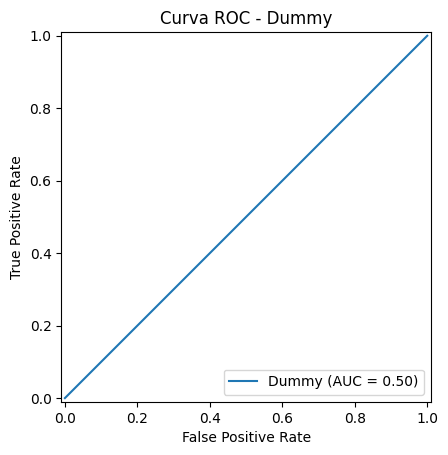

ROC-AUC Score: 0.5000


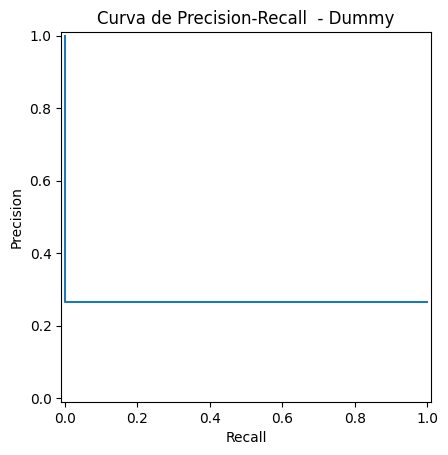

In [1180]:
evaluacion_curvas(X_train, y_train, X_test, y_test, dummy, 'Dummy')

In [1181]:
import joblib

joblib.dump(dummy, "dummy_baseline.joblib")
print("✅ dummy_baseline.joblib guardado")


✅ dummy_baseline.joblib guardado


## Balanceo de datos

In [1182]:
from imblearn.over_sampling import SMOTE

In [1183]:
def balanceo_datos(X_train, y_train):
  smote = SMOTE(random_state=42)
  X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

  print("Distribución original:\n", y_train.value_counts())
  print("\nDistribución balanceada:\n", y_train_bal.value_counts())

  return X_train_bal, y_train_bal

In [1184]:
X_train_bal, y_train_bal = balanceo_datos(X_train, y_train)

Distribución original:
 churn
0    2351
1     849
Name: count, dtype: int64

Distribución balanceada:
 churn
0    2351
1    2351
Name: count, dtype: int64


In [1185]:
X['gender'].value_counts()

,count
gender,
1,2041
0,1959


## Generación de modelo

In [1186]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [1187]:
def evaluacion_matriz_confusion(y_validacion, y_prevista):
  print(classification_report(y_validacion,y_prevista))

  matriz_confusion = confusion_matrix(y_validacion,y_prevista)
  visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion, display_labels=['No Churn','Churn'])
  visualizacion.plot()

  ax = plt.gca()
  ax.grid(False)
  plt.show()

In [1188]:
def generacion_evaluacion_modelo(X_train, y_train, X_test, y_test, model):
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train[no_categoricas])
  X_test_scaled = scaler.transform(X_test[no_categoricas])
  model.fit(X_train_scaled, y_train)

  y_pred = model.predict(X_test_scaled)
  y_proba = model.predict_proba(X_test_scaled)[:, 1]

  evaluacion_matriz_confusion(y_test, y_pred)

  print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
  print("\nClassification Report:\n")
  print(classification_report(y_test, y_pred, zero_division=0))
  print('-'*20)
  print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
  print(f"Precision: {precision_score(y_test, y_pred)}")
  print(f"Recall: {recall_score(y_test, y_pred)}")
  print(f"F1: {f1_score(y_test, y_pred)}")


### Evaluación con datos sin balancear

#### Regresión Logística

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       588
           1       0.80      0.89      0.84       212

    accuracy                           0.91       800
   macro avg       0.88      0.90      0.89       800
weighted avg       0.92      0.91      0.91       800



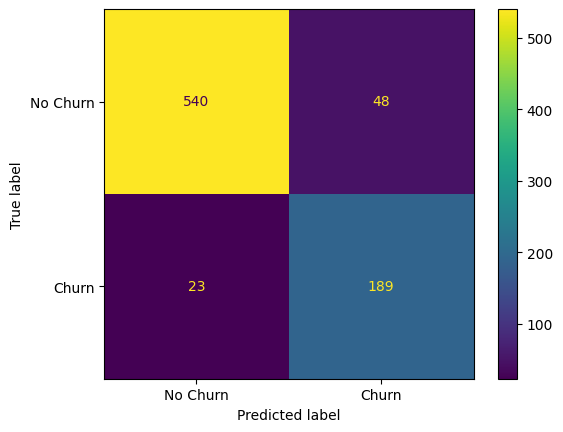

Confusion Matrix:
 [[540  48]
 [ 23 189]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       588
           1       0.80      0.89      0.84       212

    accuracy                           0.91       800
   macro avg       0.88      0.90      0.89       800
weighted avg       0.92      0.91      0.91       800

--------------------
Accuracy: 0.91125
Precision: 0.7974683544303798
Recall: 0.8915094339622641
F1: 0.8418708240534521


In [1189]:
regresion =  LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
generacion_evaluacion_modelo(X_train, y_train, X_test, y_test, regresion)

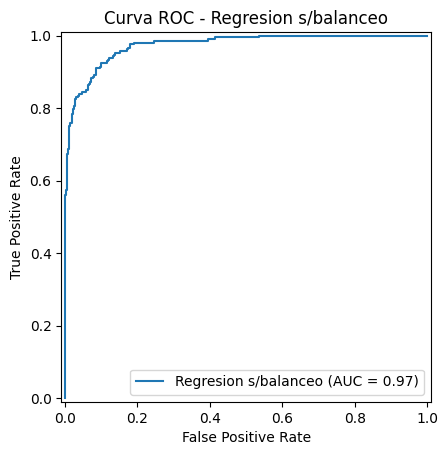

ROC-AUC Score: 0.9738


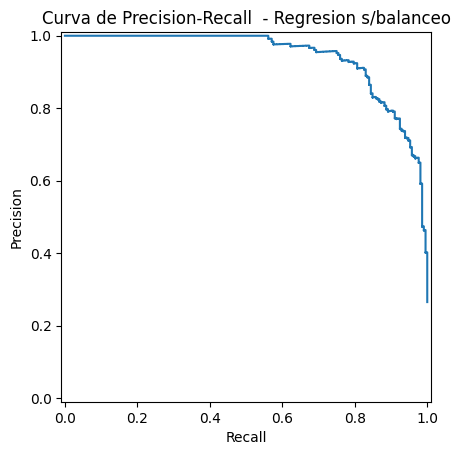

In [1190]:
evaluacion_curvas(X_train, y_train, X_test, y_test, regresion, 'Regresion s/balanceo')

#### Random Forest

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       588
           1       0.89      0.81      0.85       212

    accuracy                           0.92       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.92      0.92       800



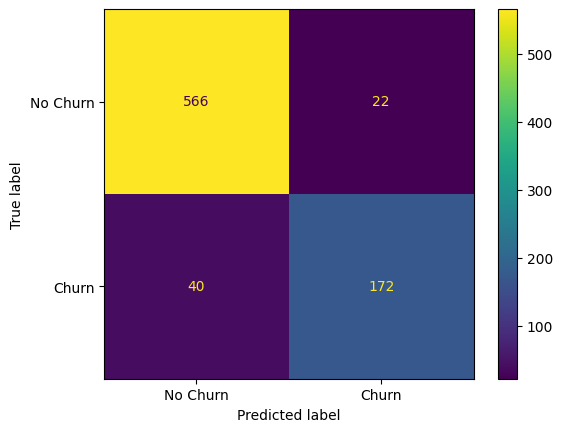

Confusion Matrix:
 [[566  22]
 [ 40 172]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       588
           1       0.89      0.81      0.85       212

    accuracy                           0.92       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.92      0.92       800

--------------------
Accuracy: 0.9225
Precision: 0.8865979381443299
Recall: 0.8113207547169812
F1: 0.8472906403940886


In [1191]:
RF =  RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
generacion_evaluacion_modelo(X_train, y_train, X_test, y_test, RF)

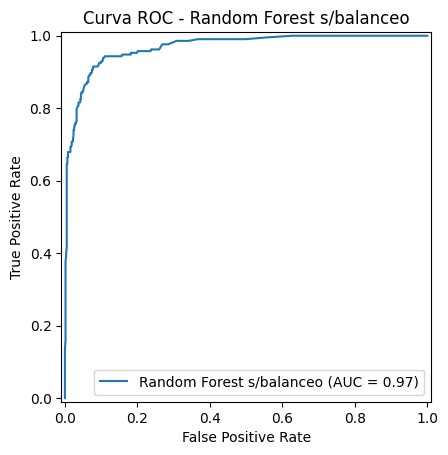

ROC-AUC Score: 0.9686


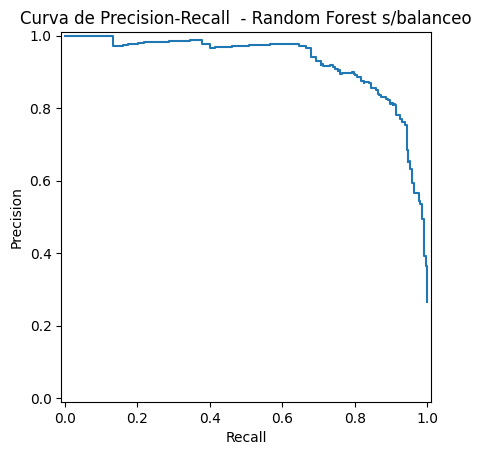

In [1192]:
evaluacion_curvas(X_train, y_train, X_test, y_test, RF, 'Random Forest s/balanceo')

### Evaluación con datos  balanceados

#### Regresión Logística

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       588
           1       0.82      0.87      0.85       212

    accuracy                           0.92       800
   macro avg       0.89      0.90      0.89       800
weighted avg       0.92      0.92      0.92       800



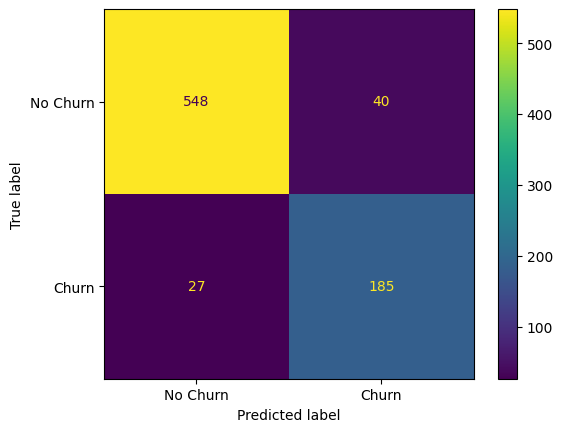

Confusion Matrix:
 [[548  40]
 [ 27 185]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       588
           1       0.82      0.87      0.85       212

    accuracy                           0.92       800
   macro avg       0.89      0.90      0.89       800
weighted avg       0.92      0.92      0.92       800

--------------------
Accuracy: 0.91625
Precision: 0.8222222222222222
Recall: 0.8726415094339622
F1: 0.8466819221967964


In [1193]:
regresion =  LogisticRegression(max_iter=2000, random_state=42)
generacion_evaluacion_modelo(X_train_bal, y_train_bal, X_test, y_test, regresion)

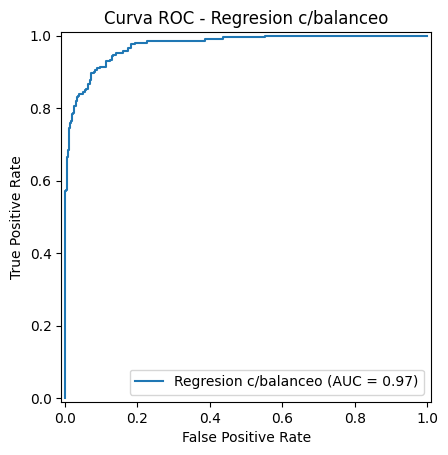

ROC-AUC Score: 0.9737


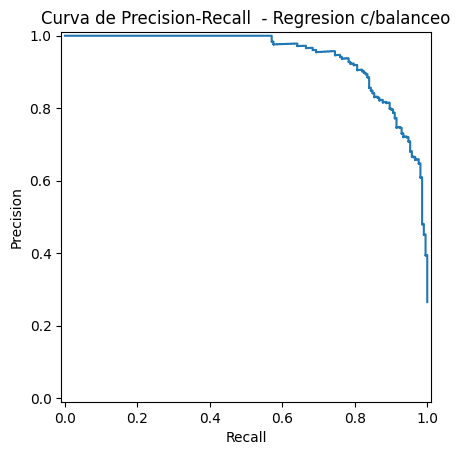

In [1194]:
evaluacion_curvas(X_train_bal, y_train_bal, X_test, y_test, regresion, 'Regresion c/balanceo')

#### Random Forest

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       588
           1       0.85      0.85      0.85       212

    accuracy                           0.92       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.92      0.92      0.92       800



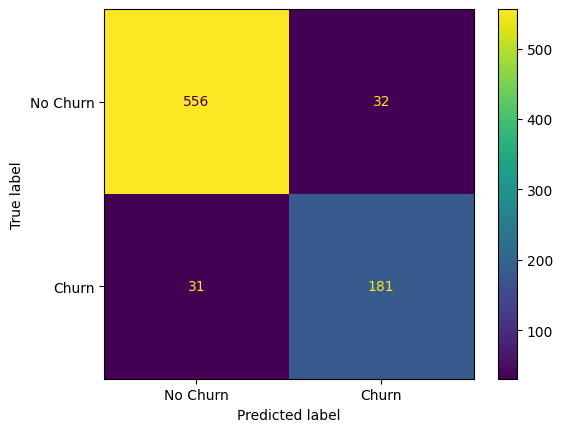

Confusion Matrix:
 [[556  32]
 [ 31 181]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       588
           1       0.85      0.85      0.85       212

    accuracy                           0.92       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.92      0.92      0.92       800

--------------------
Accuracy: 0.92125
Precision: 0.8497652582159625
Recall: 0.8537735849056604
F1: 0.851764705882353


In [1195]:
RF =  RandomForestClassifier(n_estimators=100, random_state=42)
generacion_evaluacion_modelo(X_train_bal, y_train_bal, X_test, y_test, RF)

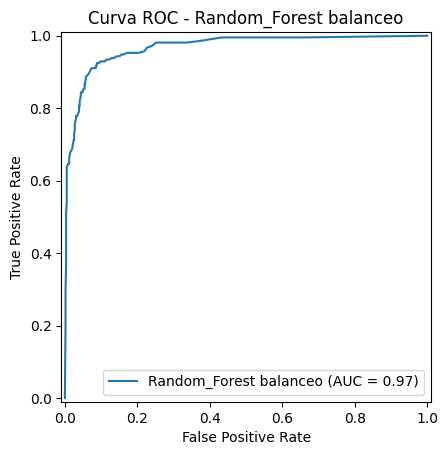

ROC-AUC Score: 0.9680


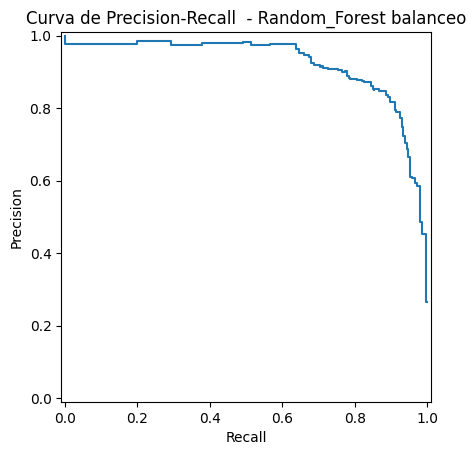

In [1196]:
evaluacion_curvas(X_train_bal, y_train_bal, X_test, y_test, RF, 'Random_Forest balanceo')

### Validación cruzada

In [1197]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [1198]:
def validacion_cruzada(X, y, model):
  preprocess = ColumnTransformer(
      transformers=[
          ("num", StandardScaler(), no_categoricas),
          ("cat", "passthrough", categoricas)
      ]
  )
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", model)
  ])

  scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
  }
  cv_results = cross_validate(
    pipe,
    X, # 👈 OJO: train ORIGINAL, sin SMOTE
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
  )
  return pd.DataFrame(cv_results).agg(["mean", "std"])

In [1199]:
def validacion_cruzada_sin_balanceo(X, y, model):
  preprocess = ColumnTransformer(
      transformers=[
          ("num", StandardScaler(), no_categoricas),
          ("cat", "passthrough", categoricas)
      ]
  )
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
  ])

  scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
  }
  cv_results = cross_validate(
    pipe,
    X, # 👈 OJO: train ORIGINAL, sin SMOTE
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
  )
  return pd.DataFrame(cv_results).agg(["mean", "std"])

#### Regresión logística

In [1200]:
validacion_cruzada(X_train, y_train, regresion)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
mean,0.18,0.07,0.92,0.80,0.91,0.85
std,0.04,0.03,0.01,0.02,0.02,0.02


In [1201]:
validacion_cruzada_sin_balanceo(X_train, y_train, regresion)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
mean,0.04,0.03,0.93,0.88,0.84,0.86
std,0.01,0.01,0.01,0.02,0.02,0.02


#### Random Forest

In [1202]:
validacion_cruzada(X_train, y_train, RF)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
mean,1.74,0.09,0.91,0.83,0.84,0.83
std,0.19,0.01,0.02,0.03,0.02,0.03


In [1203]:
validacion_cruzada_sin_balanceo(X_train, y_train, RF)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
mean,1.22,0.10,0.92,0.87,0.82,0.84
std,0.17,0.05,0.01,0.04,0.03,0.03


## Exportación de modelo

In [1204]:
def exportacion_modelo(model, name):
  joblib.dump(model, f"{name}.joblib")
  print(f"✅ {name}.joblib guardado")

### Prueba de predicción

In [1205]:
def prediccion_modelo(model, sample):
  scaler = StandardScaler()
  sample_scaled = scaler.fit_transform(sample[no_categoricas])
  pred = model.predict(sample_scaled)[0]
  proba = model.predict_proba(sample_scaled)[0, 1]
  print("SMOKE TEST OK ✅")
  print("Predicción:", pred)
  print("Probabilidad:", round(proba, 4))

#### Regresion Logística

In [1206]:
sample = X_test.iloc[[0]]
prediccion_modelo(regresion, sample)

SMOKE TEST OK ✅
Predicción: 0
Probabilidad: 0.2618


####Random Forest

In [1207]:
prediccion_modelo(RF, sample)

SMOKE TEST OK ✅
Predicción: 0
Probabilidad: 0.3


## Poda de Variables (Feature Selection)

### Regresion Logística

#### Análisis de Importancia

In [1208]:
from sklearn.inspection import permutation_importance

In [1209]:
def analisis_importancia(model, X_train, y_train):
  preprocess = ColumnTransformer(
      transformers=[
          ("num", StandardScaler(), no_categoricas),
          ("cat", "passthrough", categoricas)
      ]
  )
  pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', model)
  ])
  pipe.fit(X_train, y_train)

  # y_prevista = pd.DataFrame({'churn': pipe.predict(X_train)})
  # matriz= evaluacion_matriz_confusion(y_train, y_prevista)
  # curva = evaluacion_curvas(y_train, X_train, pipe, f'{model}')
  result = permutation_importance(pipe, X_train, y_train, scoring='recall',n_repeats=10,random_state=42)
  result_model = {
    'feature':X_train.columns, 'importance_mean':result.importances_mean, 'importance_std':result.importances_std
  }
  importance_df = pd.DataFrame(result_model).sort_values(by='importance_mean',ascending=False)
  importance_df.reset_index(drop=True)

  return importance_df

##### Generación de un pipe

In [1210]:
def evaluacion_curvas_pipe(y_scores, y_test, name):
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(
        fpr=fpr,
        tpr=tpr,
        roc_auc=roc_auc,
        estimator_name=name
    ).plot()

    plt.title(f'Curva ROC - {name}')
    plt.show()

    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_scores):.4f}")

    # Precision-Recall Curve
    precisions, recalls, thresholds = precision_recall_curve(
        y_test, y_scores
    )

    PrecisionRecallDisplay(
        precision=precisions,
        recall=recalls
    ).plot()

    plt.title(f'Curva Precision-Recall - {name}')
    plt.show()

In [1211]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['contractPeriod', 'age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyTotal',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['gender', 'nearLocation',
                                                   'partner', 'promoFriends',
                                                   'phone', 'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [1212]:
y_pred = pipe.predict(X_test)

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       588
           1       0.84      0.90      0.87       212

    accuracy                           0.93       800
   macro avg       0.90      0.92      0.91       800
weighted avg       0.93      0.93      0.93       800



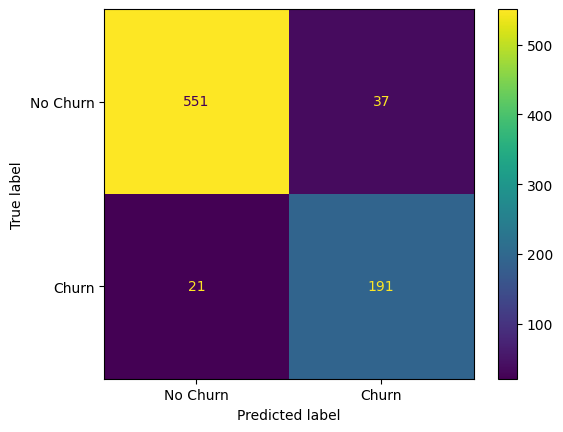

In [1213]:
evaluacion_matriz_confusion(y_test, y_pred)

In [1214]:
y_scores = pipe.predict_proba(X_test)[:, 1]

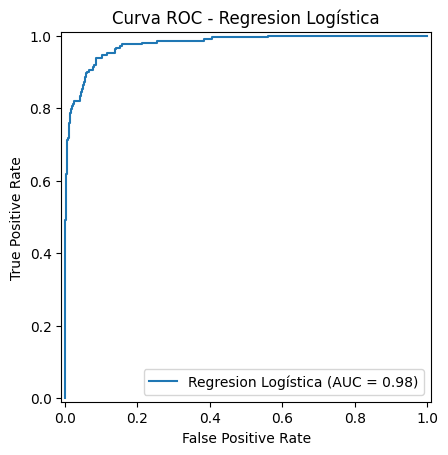

ROC-AUC Score: 0.9769


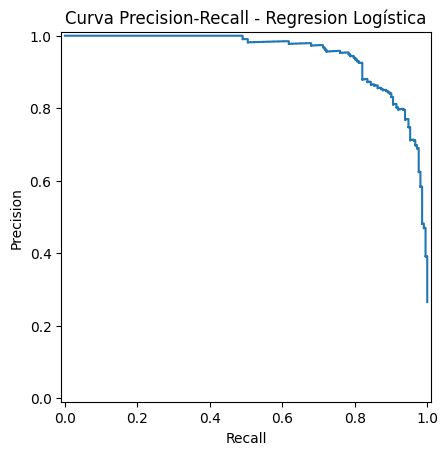

In [1215]:
evaluacion_curvas_pipe(y_scores, y_test, 'Regresion Logística')

Se hace una evaluación con datos no balanceados. El modelo mostró el mejor comportamiento sin los datos balanceados.

In [1216]:
regresion =  LogisticRegression(max_iter=2000, random_state=42)

In [1217]:
importance_regresion= analisis_importancia(regresion, X_train_bal, y_train_bal)

In [1218]:
importance_regresion

,feature,importance_mean,importance_std
12,avgClassFrequencyCurrentMonth,0.27,0.01
10,lifetime,0.21,0.01
11,avgClassFrequencyTotal,0.07,0.00
7,age,0.04,0.00
9,monthToEndContract,0.01,0.00
8,avgAdditionalChargesTotal,0.01,0.00
5,contractPeriod,0.01,0.00
6,groupVisits,0.01,0.00
3,promoFriends,0.00,0.00
2,partner,0.00,0.00


Se utilizó la técnica de Permutation Feature Importance, la cual evalúa el impacto real de cada variable en el desempeño del modelo, midiendo la caída del recall al romper la relación entre la variable y el objetivo.
Los resultados nos indican que las variables que muestran un impacto nulo o marginal son las siguientes:

In [1219]:
importance_regresion[importance_regresion['importance_mean']<=0].style.format({'importance_mean':'{:.6f}'.format})

,feature,importance_mean,importance_std
4,phone,-0.000936,0.000966
1,nearLocation,-0.001446,0.001028
0,gender,-0.001616,0.000707


In [1220]:
variables_a_eliminar = importance_regresion[importance_regresion['importance_mean']<=0]['feature'].tolist()
variables_a_eliminar

['phone', 'nearLocation', 'gender']

#### Eliminación de "Ruido"

In [1221]:
X_reducido = X.drop(columns=variables_a_eliminar)
X_reducido

,partner,promoFriends,contractPeriod,groupVisits,age,avgAdditionalChargesTotal,monthToEndContract,lifetime,avgClassFrequencyTotal,avgClassFrequencyCurrentMonth
0,1,1,6,1,29,14.23,5,3,0.02,0.00
1,0,0,12,1,31,113.20,12,7,1.92,1.91
2,1,0,1,0,28,129.45,1,2,1.86,1.74
3,1,1,12,1,33,62.67,12,2,3.21,3.36
4,1,1,1,0,26,198.36,1,3,1.11,1.12
...,...,...,...,...,...,...,...,...,...,...
3995,1,0,12,0,33,2.41,12,8,2.28,2.35
3996,0,0,1,1,29,68.88,1,1,1.28,0.29
3997,1,1,12,0,28,78.25,11,2,2.79,2.83
3998,1,1,6,0,32,61.91,5,3,1.63,1.60


In [1222]:
no_categoricas = []
categoricas = []
for col in X_reducido.columns:
  if len(df[col].unique()) == 2:
    print(f'Valores para columna {col} son {X_reducido[col].unique()}')
    categoricas.append(col)
  else:
    no_categoricas.append(col)

Valores para columna partner son [1 0]
Valores para columna promoFriends son [1 0]
Valores para columna groupVisits son [1 0]


In [1223]:
X_train_red, X_test_red, y_train, y_test = train_test_split(X_reducido,y, test_size=0.20, random_state=42,stratify=y)

In [1224]:
X_train_red.columns


Index(['partner', 'promoFriends', 'contractPeriod', 'groupVisits', 'age',
       'avgAdditionalChargesTotal', 'monthToEndContract', 'lifetime',
       'avgClassFrequencyTotal', 'avgClassFrequencyCurrentMonth'],
      dtype='object')

In [1225]:
print("Churn Train:", y_train.mean())
print("Churn Test :", y_test.mean())

Churn Train: 0.2653125
Churn Test : 0.265


In [1226]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

pipe.fit(X_train_red, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['contractPeriod', 'age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyTotal',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['partner', 'promoFriends',
                                                   'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [1227]:
y_pred = pipe.predict(X_test_red)

In [1228]:
y_pred = pd.DataFrame({'churn': y_pred})

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       588
           1       0.83      0.91      0.87       212

    accuracy                           0.93       800
   macro avg       0.90      0.92      0.91       800
weighted avg       0.93      0.93      0.93       800



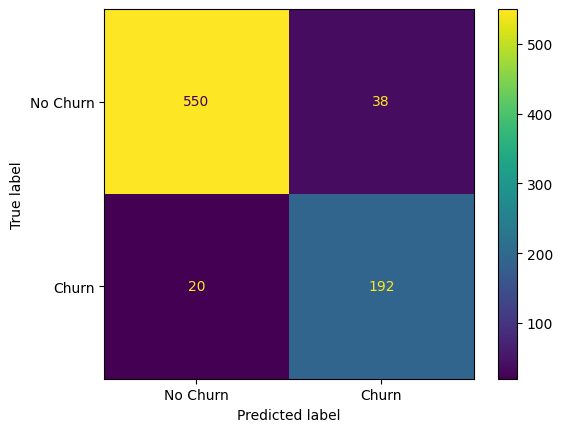

In [1229]:
evaluacion_matriz_confusion(y_test, y_pred)

In [1230]:
y_scores = pipe.predict_proba(X_test_red)[:, 1]

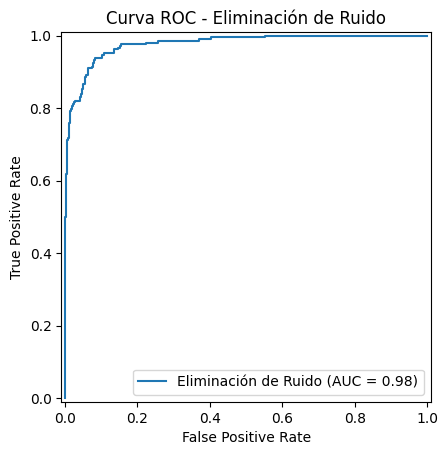

ROC-AUC Score: 0.9771


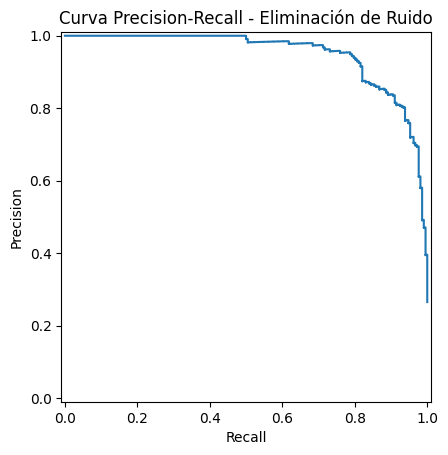

In [1231]:
evaluacion_curvas_pipe(y_scores, y_test, 'Eliminación de Ruido')

#### Multicolinealidad

In [1232]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

In [1233]:
X_const = add_constant(X_train_red)
X_const.head()

,const,partner,promoFriends,contractPeriod,groupVisits,age,avgAdditionalChargesTotal,monthToEndContract,lifetime,avgClassFrequencyTotal,avgClassFrequencyCurrentMonth
153,1.00,0,0,1,0,31,329.55,1,1,2.66,2.71
1248,1.00,1,1,6,1,26,23.27,6,4,2.16,2.16
2759,1.00,0,0,6,1,31,170.97,6,1,2.65,2.58
3529,1.00,1,1,12,1,28,91.17,5,7,1.56,1.61
2119,1.00,0,0,1,0,26,58.21,1,0,0.00,0.40


In [1234]:
def calculo_VIF(dataFrame):
  pd.options.display.float_format = '{:.2f}'.format
  vif_data = pd.DataFrame()
  vif_data["Variable"] = dataFrame.columns
  vif_data["VIF"] = [vif(dataFrame.values, i) for i in range(dataFrame.shape[1])]
  return vif_data.sort_values(by="VIF", ascending=False)

In [1235]:
calculo_VIF(X_const)

,Variable,VIF
0,const,91.62
3,contractPeriod,21.83
7,monthToEndContract,21.58
10,avgClassFrequencyCurrentMonth,12.49
9,avgClassFrequencyTotal,11.90
1,partner,1.33
2,promoFriends,1.30
8,lifetime,1.14
5,age,1.10
4,groupVisits,1.05


In [1236]:
X_const_drop_1 = X_const.drop(columns=['contractPeriod'])

In [1237]:
# calculo_VIF(X_const_drop_1)

In [1238]:
# X_const_drop_2 = X_const_drop_1.drop(columns='avgClassFrequencyTotal')
# X_const_drop_2.head()

In [1239]:
# calculo_VIF(X_const_drop_2)

In [1240]:
# X_train_VIF = X_const_drop_2.drop(columns='const')
X_train_VIF = X_const_drop_1.drop(columns='const')
X_train_VIF.head()

,partner,promoFriends,groupVisits,age,avgAdditionalChargesTotal,monthToEndContract,lifetime,avgClassFrequencyTotal,avgClassFrequencyCurrentMonth
153,0,0,0,31,329.55,1,1,2.66,2.71
1248,1,1,1,26,23.27,6,4,2.16,2.16
2759,0,0,1,31,170.97,6,1,2.65,2.58
3529,1,1,1,28,91.17,5,7,1.56,1.61
2119,0,0,0,26,58.21,1,0,0.00,0.40


In [1241]:
columnas_VIF = X_train_VIF.columns.to_list()

In [1242]:
X_test_red_VIF = X_test_red[columnas_VIF]
X_test_red_VIF.head()

,partner,promoFriends,groupVisits,age,avgAdditionalChargesTotal,monthToEndContract,lifetime,avgClassFrequencyTotal,avgClassFrequencyCurrentMonth
1799,1,0,1,29,21.26,1,7,0.50,0.50
2296,0,0,1,29,98.34,1,1,2.85,2.84
1177,0,0,0,31,66.33,1,1,1.06,0.75
3375,1,0,0,28,59.89,9,2,1.79,1.60
2206,1,1,0,28,146.36,7,5,2.45,2.40


In [1243]:
# X_train_VIF, X_test_red_VIF, y_train, y_test

In [1244]:
no_categoricas = []
categoricas = []
for col in X_train_VIF.columns:
  if len(df[col].unique()) == 2:
    print(f'Valores para columna {col} son {X_train_VIF[col].unique()}')
    categoricas.append(col)
  else:
    no_categoricas.append(col)

Valores para columna partner son [0 1]
Valores para columna promoFriends son [0 1]
Valores para columna groupVisits son [0 1]


In [1245]:
print("Churn Train:", y_train.mean())
print("Churn Test :", y_test.mean())

Churn Train: 0.2653125
Churn Test : 0.265


In [1246]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

pipe.fit(X_train_VIF, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyTotal',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['partner', 'promoFriends',
                                                   'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [1247]:
y_pred = pipe.predict(X_test_red_VIF)

In [1248]:
y_pred = pd.DataFrame({'churn': y_pred})

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       588
           1       0.83      0.90      0.87       212

    accuracy                           0.93       800
   macro avg       0.90      0.92      0.91       800
weighted avg       0.93      0.93      0.93       800



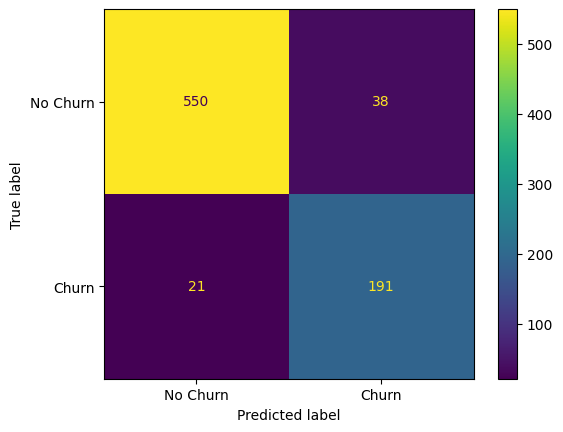

In [1249]:
evaluacion_matriz_confusion(y_test, y_pred)

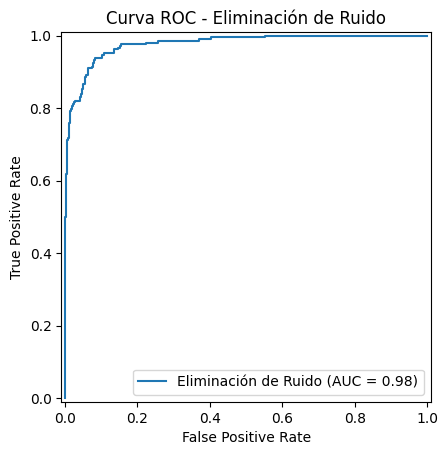

ROC-AUC Score: 0.9771


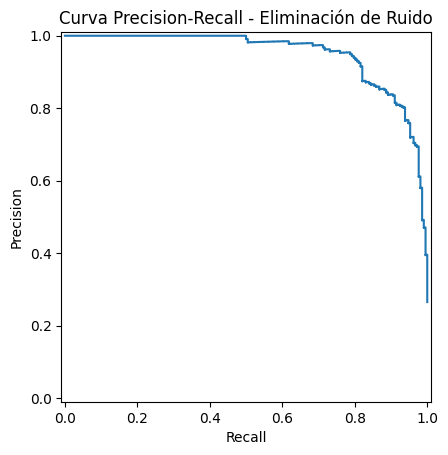

In [1250]:
evaluacion_curvas_pipe(y_scores, y_test, 'Eliminación de Ruido')

In [1251]:
sample = X_test.iloc[[0]]
sample_for_prediction = sample[columnas_VIF]

In [1252]:
pred = pipe.predict(sample_for_prediction)[0]
proba = pipe.predict_proba(sample_for_prediction)[:, 1][0]

In [1253]:
proba = pipe.predict_proba(sample_for_prediction)[0, 1]

print("SMOKE TEST OK ✅")
print("Predicción:", pred)
print("Probabilidad:", round(proba, 4))

SMOKE TEST OK ✅
Predicción: 0
Probabilidad: 0.0108


#### Optimización del modelo

In [1254]:
from sklearn.model_selection import GridSearchCV

In [1255]:
param_grid = [
    {
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear'],
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [2000]
    },
    {
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs'],
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [2000]
    }
]

In [1256]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [1257]:
# grid.fit(X_train_VIF_bal, y_train_bal)
grid.fit(X_train_VIF, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'avgAdditionalChargesTotal',
                                                                          'monthToEndContract',
                                                                          'lifetime',
                                                                          'avgClassFrequencyTotal',
                                                                          'avgClassFrequencyCurrentMonth']),
                                                                        ('cat',
                                                                         'passthrough',
                                                                         ['partner',
                                                                          'promoFriends',
                                                                          'groupVisits'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        Lo...
             n_jobs=-1,
             param_grid=[{'model__C': [0.01, 0.1, 1, 10, 100],
                          'model__class_weight': [None, 'balanced'],
                          'model__max_iter': [2000],
                          'model__penalty': ['l1', 'l2'],
                          'model__solver': ['liblinear']},
                         {'model__C': [0.01, 0.1, 1, 10, 100],
                          'model__class_weight': [None, 'balanced'],
                          'model__max_iter': [2000], 'model__penalty': ['l2'],
                          'model__solver': ['lbfgs']}],
             scoring='roc_auc', verbose=1)

In [1258]:
grid.best_params_

{'model__C': 1,
 'model__class_weight': None,
 'model__max_iter': 2000,
 'model__penalty': 'l2',
 'model__solver': 'lbfgs'}

In [1259]:
grid.best_score_

np.float64(0.9765935363022166)

In [1260]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe_best = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, C=1,
                                 class_weight=None, penalty='l2',
                                 solver='lbfgs', random_state=42))
])

pipe_best.fit(X_train_VIF, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyTotal',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['partner', 'promoFriends',
                                                   'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(C=1, max_iter=2000, random_state=42))])

In [1261]:
y_pred = pipe_best.predict(X_test_red_VIF)

In [1262]:
y_best = pd.DataFrame({'churn': pipe_best.predict(X_test_red_VIF)})

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       588
           1       0.83      0.90      0.87       212

    accuracy                           0.93       800
   macro avg       0.90      0.92      0.91       800
weighted avg       0.93      0.93      0.93       800



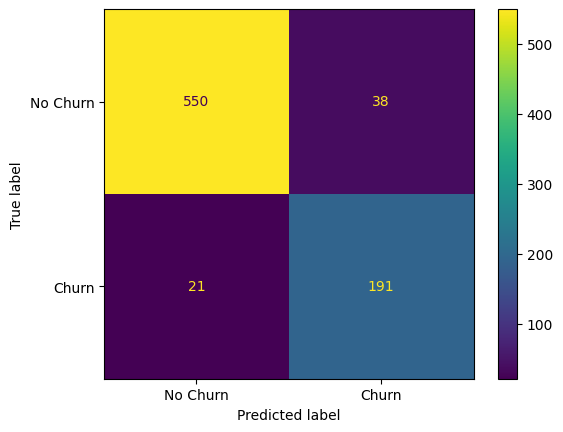

In [1269]:
evaluacion_matriz_confusion(y_test, y_best)

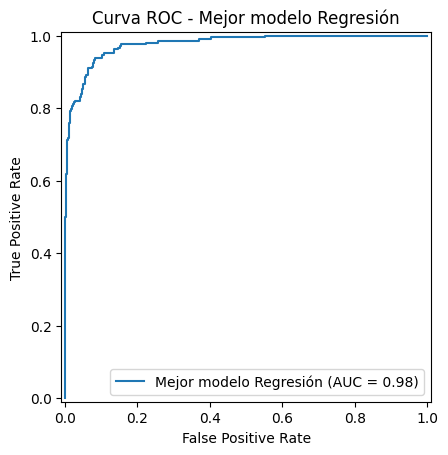

ROC-AUC Score: 0.9771


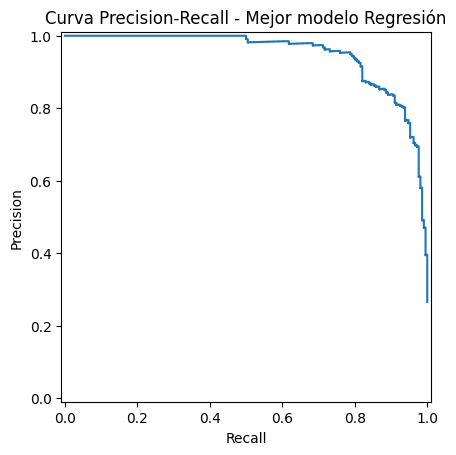

In [1270]:
evaluacion_curvas_pipe(y_scores, y_test, 'Mejor modelo Regresión')

In [1271]:
sample = X_test.iloc[[0]]
sample_for_prediction = sample[columnas_VIF]

In [1272]:
y_test.iloc[[0]]

,churn
1799,0


In [1273]:
pred = pipe.predict(sample_for_prediction)[0]
proba = pipe.predict_proba(sample_for_prediction)[:, 1][0]

In [1274]:
print("SMOKE TEST OK ✅")
print("Predicción:", pred)
print("Probabilidad:", round(proba, 4))

SMOKE TEST OK ✅
Predicción: 0
Probabilidad: 0.0108


#### Exportación del modelo

In [1275]:
exportacion_modelo(pipe_best, 'Regresion_modelo_champion')

✅ Regresion_modelo_champion.joblib guardado


##### RandomizedSearchCV

In [1067]:
from scipy.stats import loguniform

In [1068]:
param_dist_logreg = {
    "C": loguniform(1e-3, 1e3),
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

In [1072]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [1069]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [1070]:
logreg = LogisticRegression(max_iter=1000, random_state=42)

In [1073]:
rs_logreg = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_dist_logreg,
    n_iter=30,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [1078]:
rs_logreg.fit(X_train_VIF, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LogisticRegression(max_iter=1000, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f2e6c00a9c0>,
                                        'class_weight': [None, 'balanced'],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   random_state=42, scoring='recall', verbose=1)

In [1079]:
rs_logreg.best_params_

{'C': np.float64(1.9066091638188458),
 'class_weight': 'balanced',
 'penalty': 'l1',
 'solver': 'liblinear'}

In [1076]:
rs_logreg.best_score_

np.float64(0.9485296110584092)

In [1080]:
# pipe_best = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', LogisticRegression(max_iter=2000, C=0.3905441275210791,
#                                  class_weight=None, penalty='l1',
#                                  solver='liblinear', random_state=42))
# ])
# pipe_best.fit(X_train_VIF_bal, y_train_bal)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe_best = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, C=1.9066091638188458,
                                 class_weight='balanced', penalty='l1',
                                 solver='liblinear', random_state=42))
])
pipe_best.fit(X_train_VIF, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyTotal',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['partner', 'promoFriends',
                                                   'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(C=1.9066091638188458,
                                    class_weight='balanced', max_iter=2000,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [1081]:
y_prevista_VIF = pd.DataFrame({'churn': pipe.predict(X_test_red_VIF)})

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       588
           1       0.83      0.90      0.87       212

    accuracy                           0.93       800
   macro avg       0.90      0.92      0.91       800
weighted avg       0.93      0.93      0.93       800



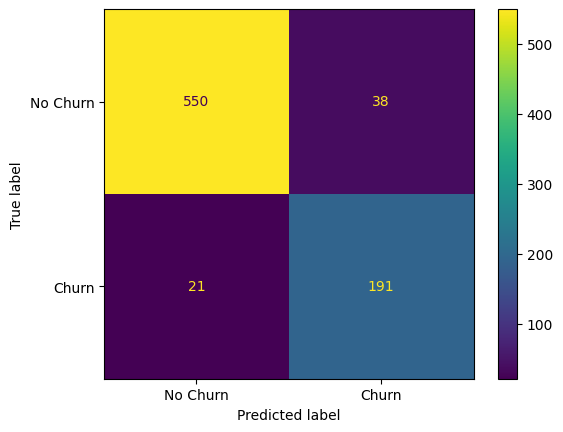

In [1082]:
evaluacion_matriz_confusion(y_test, y_prevista_VIF)

### Random Forest

#### Análisis de Importancia

In [1128]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Churn Train:", y_train.mean())
print("Churn Test :", y_test.mean())

Churn Train: 0.2653125
Churn Test : 0.265


In [1088]:
no_categoricas = []
categoricas = []
for col in X.columns:
  if len(df[col].unique()) == 2:
    print(f'Valores para columna {col} son {X[col].unique()}')
    categoricas.append(col)
  else:
    no_categoricas.append(col)

Valores para columna gender son [1 0]
Valores para columna nearLocation son [1 0]
Valores para columna partner son [1 0]
Valores para columna promoFriends son [1 0]
Valores para columna phone son [0 1]
Valores para columna groupVisits son [1 0]


In [1089]:
# pipe = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', RandomForestClassifier(n_estimators=100, random_state=42))
# ])
# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), no_categoricas),
#         ("cat", "passthrough", categoricas)
#     ]
# )
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['contractPeriod', 'age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyTotal',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['gender', 'nearLocation',
                                                   'partner', 'promoFriends',
                                                   'phone', 'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

In [1090]:
y_prevista = pd.DataFrame({'churn': pipe.predict(X_test)})

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       588
           1       0.85      0.85      0.85       212

    accuracy                           0.92       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.92      0.92      0.92       800



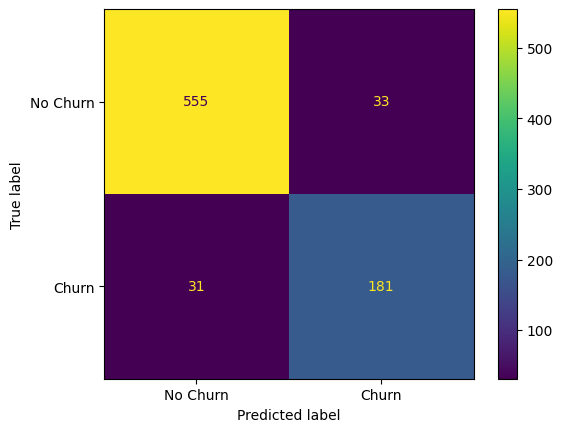

In [1096]:
evaluacion_matriz_confusion(y_test, y_prevista)

In [1094]:
y_scores = pipe.predict_proba(X_test)[:, 1]

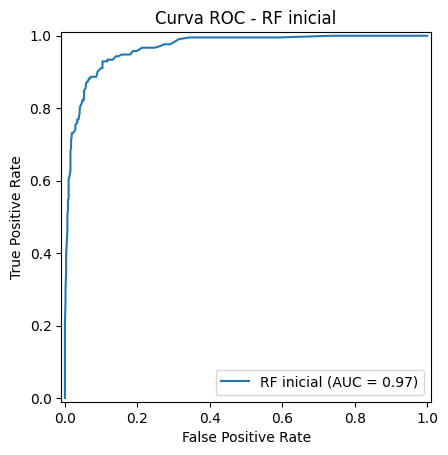

ROC-AUC Score: 0.9672


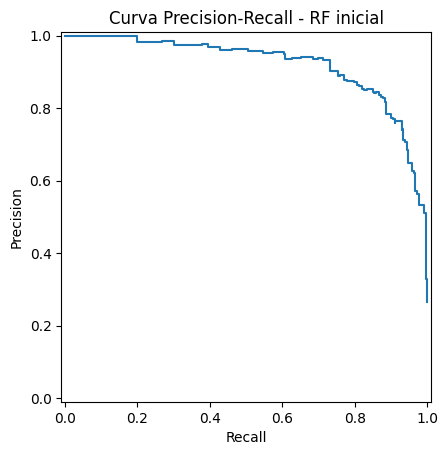

In [1095]:
evaluacion_curvas_pipe(y_scores, y_test, 'RF inicial')

In [1097]:
result = permutation_importance(pipe, X_test, y_test, scoring='recall',n_repeats=10,random_state=42)

In [1098]:
result_model = {
    'feature':X_test.columns, 'importance_mean':result.importances_mean, 'importance_std':result.importances_std
}

In [1099]:
importance_df = pd.DataFrame(result_model).sort_values(by='importance_mean',ascending=False)
importance_df.reset_index(drop=True)

,feature,importance_mean,importance_std
0,lifetime,0.36,0.03
1,age,0.09,0.02
2,avgClassFrequencyCurrentMonth,0.06,0.01
3,contractPeriod,0.04,0.01
4,monthToEndContract,0.03,0.01
5,avgAdditionalChargesTotal,0.03,0.02
6,groupVisits,0.02,0.01
7,promoFriends,0.01,0.01
8,phone,0.01,0.00
9,partner,0.00,0.01


In [1101]:
importance_df[importance_df['importance_mean']<=0.003]

,feature,importance_mean,importance_std
2,partner,0.00,0.01
1,nearLocation,0.00,0.00
11,avgClassFrequencyTotal,-0.00,0.01
0,gender,-0.01,0.00


In [1102]:
variables_a_eliminar = importance_df[importance_df['importance_mean']<=0.003]['feature'].tolist()
# variables_a_eliminar = 'phone'

In [1108]:
variables_a_eliminar

['partner', 'nearLocation', 'avgClassFrequencyTotal', 'gender']

Nota: Se realizaron diferentes escenarios para eliminar variables en función del análisis de importancia. Dicha eliminación se observó que impactaba directamente al desempeño del método random Forest, lo que implicaría que dichas variables contribuyen al comportamiento del método. Se determinó que solamente la columna phone es una de las que no contribuyen al entrenamiento.

#### Eliminación de "Ruido"

In [1109]:
X_reducido = X.drop(columns=variables_a_eliminar)
X_reducido

,promoFriends,phone,contractPeriod,groupVisits,age,avgAdditionalChargesTotal,monthToEndContract,lifetime,avgClassFrequencyCurrentMonth
0,1,0,6,1,29,14.23,5,3,0.00
1,0,1,12,1,31,113.20,12,7,1.91
2,0,1,1,0,28,129.45,1,2,1.74
3,1,1,12,1,33,62.67,12,2,3.36
4,1,1,1,0,26,198.36,1,3,1.12
...,...,...,...,...,...,...,...,...,...
3995,0,1,12,0,33,2.41,12,8,2.35
3996,0,1,1,1,29,68.88,1,1,0.29
3997,1,1,12,0,28,78.25,11,2,2.83
3998,1,1,6,0,32,61.91,5,3,1.60


In [1110]:
X_train_red, X_test_red, y_train, y_test = train_test_split(X_reducido,y, test_size=0.20, random_state=42,stratify=y)

In [1111]:
print("Churn Train:", y_train.mean())
print("Churn Test :", y_test.mean())

Churn Train: 0.2653125
Churn Test : 0.265


In [1112]:
no_categoricas = []
categoricas = []
for col in X_train_red.columns:
  if len(df[col].unique()) == 2:
    print(f'Valores para columna {col} son {X_train_red[col].unique()}')
    categoricas.append(col)
  else:
    no_categoricas.append(col)

Valores para columna promoFriends son [0 1]
Valores para columna phone son [1 0]
Valores para columna groupVisits son [0 1]


In [ ]:
# X_train_red_bal, y_train_bal = balanceo_datos(X_train_red, y_train)

Distribución original:
 churn
0    2351
1     849
Name: count, dtype: int64

Distribución balanceada:
 churn
0    2351
1    2351
Name: count, dtype: int64


In [1113]:
# pipe = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', RandomForestClassifier(n_estimators=100, random_state=42))
# ])
# pipe.fit(X_train_red_bal, y_train_bal)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe.fit(X_train_red, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['contractPeriod', 'age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['promoFriends', 'phone',
                                                   'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

In [1114]:
y_prevista_red = pd.DataFrame({'churn': pipe.predict(X_test_red)})

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       588
           1       0.81      0.83      0.82       212

    accuracy                           0.90       800
   macro avg       0.87      0.88      0.87       800
weighted avg       0.90      0.90      0.90       800



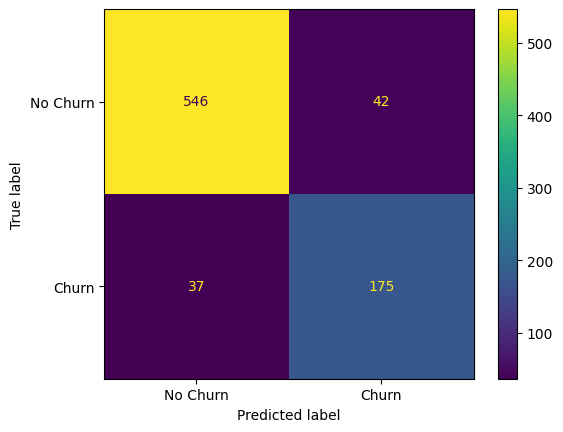

In [1115]:
evaluacion_matriz_confusion(y_test, y_prevista_red)

In [1116]:
y_scores = pipe.predict_proba(X_test_red)[:, 1]

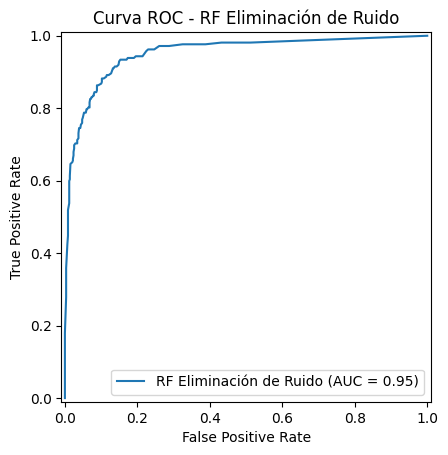

ROC-AUC Score: 0.9516


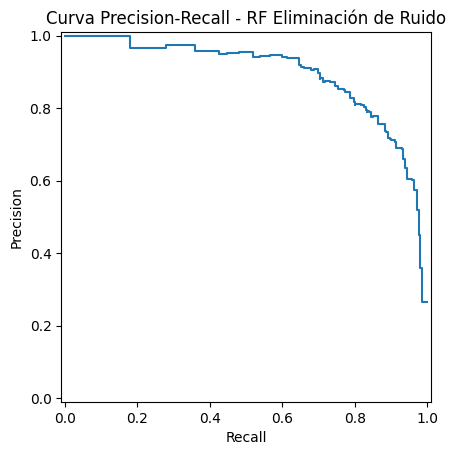

In [1117]:
evaluacion_curvas_pipe(y_scores, y_test, 'RF Eliminación de Ruido')

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       588
           1       0.84      0.87      0.86       212

    accuracy                           0.92       800
   macro avg       0.90      0.91      0.90       800
weighted avg       0.92      0.92      0.92       800



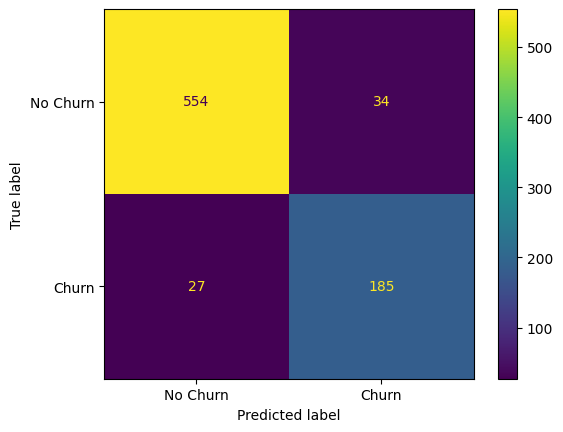

Confusion Matrix:
 [[554  34]
 [ 27 185]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       588
           1       0.84      0.87      0.86       212

    accuracy                           0.92       800
   macro avg       0.90      0.91      0.90       800
weighted avg       0.92      0.92      0.92       800

--------------------
Accuracy: 0.92375
Precision: 0.8447488584474886
Recall: 0.8726415094339622
F1: 0.8584686774941995


In [ ]:
RF =  RandomForestClassifier(n_estimators=100, random_state=42)
generacion_evaluacion_modelo(X_train_red_bal, y_train_bal, X_test_red, y_test, RF)

#### Optimización del modelo

In [1129]:
# param_grid = {
#     "n_estimators": [200, 400, 600],
#     "max_depth": [None, 10, 20, 30],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 5],
#     "max_features": ["sqrt", "log2"],
#     "bootstrap": [True]
# }

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True]
}

In [1130]:
no_categoricas = []
categoricas = []
for col in X.columns:
  if len(df[col].unique()) == 2:
    print(f'Valores para columna {col} son {X[col].unique()}')
    categoricas.append(col)
  else:
    no_categoricas.append(col)

Valores para columna gender son [1 0]
Valores para columna nearLocation son [1 0]
Valores para columna partner son [1 0]
Valores para columna promoFriends son [1 0]
Valores para columna phone son [0 1]
Valores para columna groupVisits son [1 0]


In [1131]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), no_categoricas),
        ("cat", "passthrough", categoricas)
    ]
)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

In [1132]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [1127]:
# grid = GridSearchCV(
#     estimator=RandomForestClassifier(
#         random_state=42,
#         n_jobs=-1
#     ),
#     param_grid=param_grid,
#     cv=5,
#     scoring="recall",
#     n_jobs=-1,
#     verbose=2
# )
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [1133]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['contractPeriod',
                                                                          'age',
                                                                          'avgAdditionalChargesTotal',
                                                                          'monthToEndContract',
                                                                          'lifetime',
                                                                          'avgClassFrequencyTotal',
                                                                          'avgClassFrequencyCurrentMonth']),
                                                                        ('cat',
                                                                         'passthrough',
                                                                         ['gender',
                                                                          'nearLo...
                                                                          'phone',
                                                                          'groupVisits'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__bootstrap': [True],
                         'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 5],
                         'model__min_samples_split': [2, 10],
                         'model__n_estimators': [200, 400]},
             scoring='recall', verbose=2)

In [1134]:
grid.best_params_

{'model__bootstrap': True,
 'model__max_depth': 10,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 5,
 'model__min_samples_split': 2,
 'model__n_estimators': 200}

In [1135]:
grid.best_score_

np.float64(0.8668639053254438)

In [ ]:
# pipe_best = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', RandomForestClassifier(bootstrap=True, max_depth=10, max_features='sqrt',min_samples_leaf=1,min_samples_split=2, n_estimators=600, random_state=42))
# ])
# pipe_best.fit(X_train_red_bal, y_train_bal)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=600,
                                        random_state=42))])

In [1142]:
y_best = best_model.predict(X_test)

In [1143]:
best_model = grid.best_estimator_

In [1144]:
y_scores = best_model.predict_proba(X_test)[:, 1]

In [1145]:
y_scores = pd.DataFrame({'churn': y_scores})

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       588
           1       0.82      0.86      0.84       212

    accuracy                           0.91       800
   macro avg       0.89      0.90      0.89       800
weighted avg       0.92      0.91      0.91       800



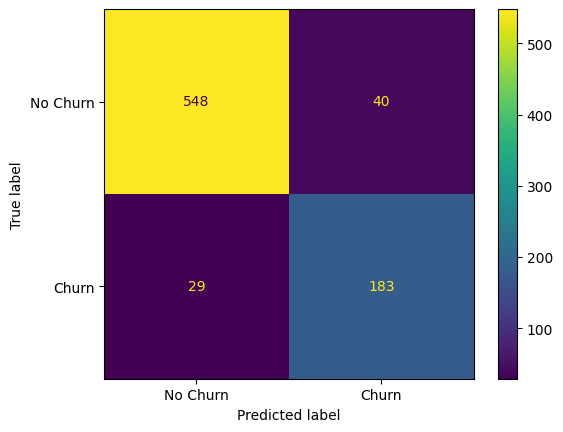

In [1146]:
evaluacion_matriz_confusion(y_test, y_best)

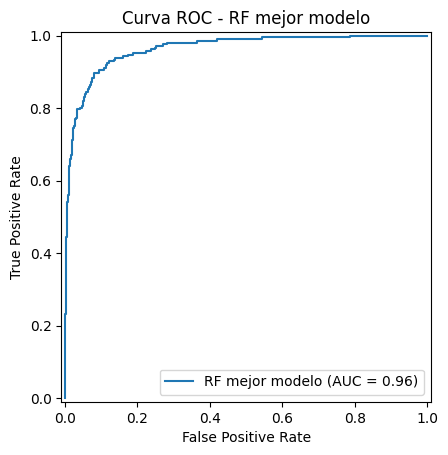

ROC-AUC Score: 0.9639


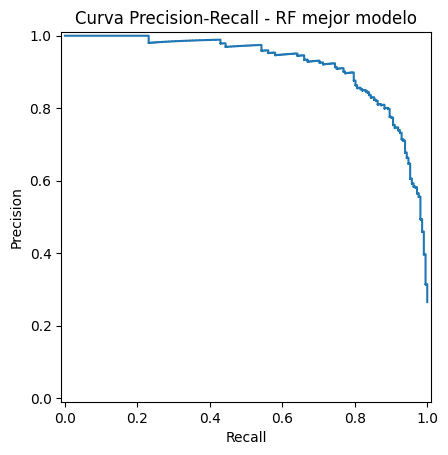

In [1148]:
evaluacion_curvas_pipe(y_scores, y_test, 'RF mejor modelo')

#### Exportación del modelo

In [1161]:
best_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['contractPeriod', 'age',
                                                   'avgAdditionalChargesTotal',
                                                   'monthToEndContract',
                                                   'lifetime',
                                                   'avgClassFrequencyTotal',
                                                   'avgClassFrequencyCurrentMonth']),
                                                 ('cat', 'passthrough',
                                                  ['gender', 'nearLocation',
                                                   'partner', 'promoFriends',
                                                   'phone', 'groupVisits'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=5,
                                        n_estimators=200, random_state=42))])

In [1162]:
exportacion_modelo(best_model, 'RF_modelo_champion')

✅ RF_modelo_champion.joblib guardado


#### RandomizedSearchCV

In [1149]:
from scipy.stats import randint

In [1150]:
param_dist_rf = {
    "n_estimators": randint(200, 800),
    "max_depth": [None] + list(range(5, 30)),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 15),
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

In [1151]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [1152]:
rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=40,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [1154]:
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'max_depth': [None, 5, 6, 7, 8, 9, 10,
                                                      11, 12, 13, 14, 15, 16,
                                                      17, 18, 19, 20, 21, 22,
                                                      23, 24, 25, 26, 27, 28,
                                                      29],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f2e6274cda0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f2e623e0aa0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f2e6274e720>},
                   random_state=42, scoring='recall', verbose=1)

In [1155]:
best_rf = rs_rf.best_estimator_

In [1157]:
best_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=7,
                       max_features='log2', min_samples_leaf=13,
                       min_samples_split=19, n_estimators=755, n_jobs=-1,
                       random_state=42)

In [1158]:
y_best = pd.DataFrame({'churn': best_rf.predict(X_test)})

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       588
           1       0.77      0.88      0.82       212

    accuracy                           0.90       800
   macro avg       0.86      0.89      0.88       800
weighted avg       0.91      0.90      0.90       800



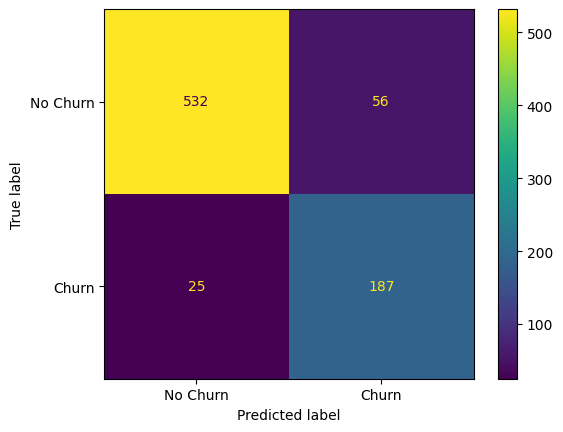

In [1159]:
evaluacion_matriz_confusion(y_test, y_best)

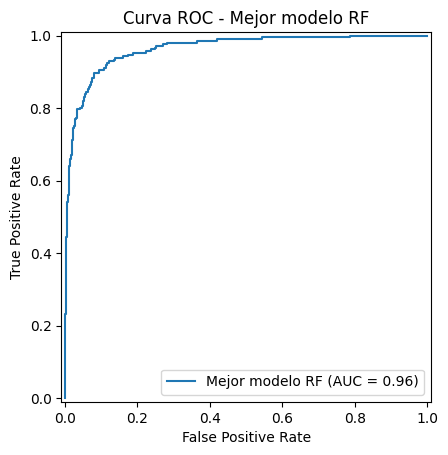

ROC-AUC Score: 0.9639


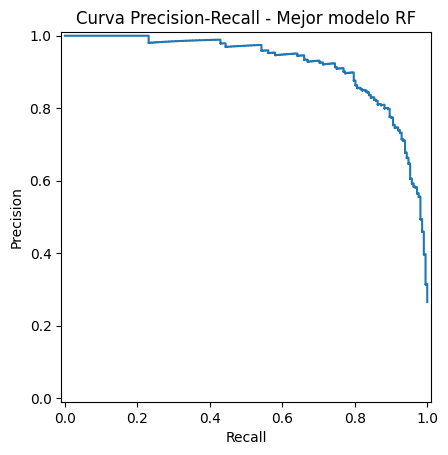

In [1160]:
evaluacion_curvas_pipe(y_scores, y_test, 'Mejor modelo RF')